========== LOADING TRAIN DATA ==========
Tổng số mẫu ảnh thực tế dùng để Train: 399

========== TRAINING MODEL ==========
Training completed!

========== TEST RESULT ==========

01. test_cat_0.jpg       Actual: cat Predict: cat ✓
02. test_cat_1.jpg       Actual: cat Predict: cat ✓
03. test_cat_10.jpg      Actual: cat Predict: dog ✗
04. test_cat_11.jpg      Actual: cat Predict: dog ✗
05. test_cat_12.jpg      Actual: cat Predict: cat ✓
06. test_cat_13.jpg      Actual: cat Predict: cat ✓
07. test_cat_14.jpg      Actual: cat Predict: dog ✗
08. test_cat_15.jpg      Actual: cat Predict: cat ✓
09. test_cat_16.jpg      Actual: cat Predict: cat ✓
10. test_cat_17.jpg      Actual: cat Predict: cat ✓
11. test_cat_18.jpg      Actual: cat Predict: cat ✓
12. test_cat_19.jpg      Actual: cat Predict: cat ✓
13. test_cat_2.jpg       Actual: cat Predict: cat ✓
14. test_cat_20.jpg      Actual: cat Predict: cat ✓
15. test_cat_21.jpg      Actual: cat Predict: cat ✓
16. test_cat_22.jpg      Actual: cat Predi

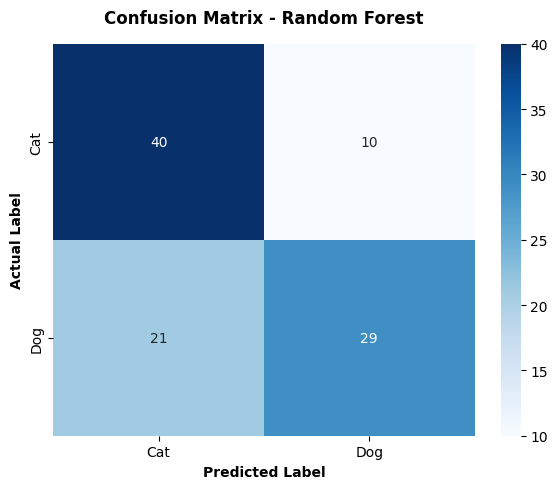

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from skimage.feature import hog, graycomatrix, graycoprops
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Tắt warning
warnings.filterwarnings("ignore")

# =====================================================
# HÀM TRÍCH XUẤT ĐẶC TRƯNG 
# =====================================================
def Extract_Advanced_Features(img_path):
    img = cv2.imread(img_path)

    if img is None:
        print(f"Không đọc được ảnh: {img_path}")
        return None

    img = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Đặc trưng màu sắc
    avg_color = np.mean(img, axis=(0, 1))

    # Đặc trưng texture (GLCM)
    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    # Đặc trưng HOG
    hog_feature = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )

    feature = np.hstack((
        avg_color,
        contrast,
        correlation,
        hog_feature
    ))

    return feature

# =====================================================
# 1. ĐỌC DỮ LIỆU TRAIN (Từ file CSV tổng hợp)
# =====================================================
csv_path = '../data/dog_cat_features.csv'

if not os.path.exists(csv_path):
    print(f"Lỗi: Không tìm thấy file {csv_path}. Hãy chạy file trích xuất đặc trưng trước!")
    exit()

print("========== LOADING TRAIN DATA ==========")
df_train = pd.read_csv(csv_path)
print(f"Tổng số mẫu ảnh thực tế dùng để Train: {len(df_train)}")

X_train = df_train.drop('Label', axis=1).values
y_train = df_train['Label'].values

# =====================================================
# 2. HUẤN LUYỆN MÔ HÌNH RANDOM FOREST (100 cây quyết định)
# =====================================================
print("\n========== TRAINING MODEL ==========")
# Cấu hình n_estimators=100 cây theo đúng nguyên lý phân loại tập hợp
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
print("Training completed!")

# =====================================================
# 3. DỰ ĐOÁN TRÊN THƯ MỤC TEST ĐỘC LẬP
# =====================================================
test_dir = "../data/test"

actual = []
predicted = []

print("\n========== TEST RESULT ==========\n")

count = 1
for category in ["cat", "dog"]:
    folder = os.path.join(test_dir, category)
    if not os.path.exists(folder):
        print("Không tìm thấy thư mục:", folder)
        continue

    for file in sorted(os.listdir(folder)):
        img_path = os.path.join(folder, file)
        feature = Extract_Advanced_Features(img_path)

        if feature is None:
            continue

        # Dự đoán trực tiếp nhãn dạng chữ ('cat' hoặc 'dog')
        pred = rf_model.predict([feature])[0]
        actual.append(category)
        predicted.append(pred)

        status = "✓" if pred == category else "✗"
        print(f"{count:02d}. {file:<20} Actual: {category:<3} Predict: {pred:<3} {status}")
        count += 1

# =====================================================
# 4. ĐÁNH GIÁ KẾT QUẢ & TRÍCH XUẤT BÁO CÁO
# =====================================================
accuracy = accuracy_score(actual, predicted)

# Cố định thứ tự nhãn ['cat', 'dog'] để bóc tách ma trận chính xác
cm = confusion_matrix(actual, predicted, labels=['cat', 'dog'])

# Giải nén các giá trị từ Confusion Matrix theo nhãn cố định
tn = cm[0, 0] # Thực tế Mèo, Máy đoán Mèo
fp = cm[0, 1] # Thực tế Mèo, Máy đoán Chó
fn = cm[1, 0] # Thực tế Chó, Máy đoán Mèo
tp = cm[1, 1] # Thực tế Chó, Máy đoán Chó

print("\n" + "="*40)
print("KẾT QUẢ ĐỂ ĐIỀN VÀO BÁO CÁO")
print("="*40)
print(f"Độ chính xác (Accuracy): {accuracy * 100:.2f}%")
print(f"True Positive (Đoán đúng Chó): {tp}")
print(f"True Negative (Đoán đúng Mèo): {tn}")
print(f"False Positive (Nhầm Mèo thành Chó): {fp}")
print(f"False Negative (Nhầm Chó thành Mèo): {fn}")
print("="*40)

print("\nClassification Report\n")
print(classification_report(actual, predicted, labels=["cat", "dog"]))

# =====================================================
# 5. VẼ VÀ LƯU HÌNH ẢNH CONFUSION MATRIX
# =====================================================
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Cat', 'Dog'], 
    yticklabels=['Cat', 'Dog']
)
plt.title('Confusion Matrix - Random Forest', fontweight='bold', pad=15)
plt.ylabel('Actual Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.show()